In [89]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Merge

In [90]:
path1 = r"D:\final project ML\nykaa_campaign_data.csv"
path2 = r"D:\final project ML\purplle_campaign_data.csv"
path3 = r"D:\final project ML\tira_campaign_data.csv"

nykaa = pd.read_csv(path1)
purplle = pd.read_csv(path2)
tira = pd.read_csv(path3)

print(nykaa.shape)
print(purplle.shape)
print(tira.shape)

(55555, 16)
(55555, 16)
(55555, 16)


In [91]:
nykaa["Brand"] = "Nykaa"
purplle["Brand"] = "Purplle"
tira["Brand"] = "Tira"

df = pd.concat([nykaa, purplle, tira], ignore_index=True)
print(df.shape)
print(df["Brand"].value_counts())

(166665, 17)
Brand
Nykaa      55555
Purplle    55555
Tira       55555
Name: count, dtype: int64


# **EDA**

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166665 entries, 0 to 166664
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       166665 non-null  object 
 1   Campaign_Type     166665 non-null  object 
 2   Target_Audience   166665 non-null  object 
 3   Duration          166665 non-null  int64  
 4   Channel_Used      166665 non-null  object 
 5   Impressions       166665 non-null  int64  
 6   Clicks            166665 non-null  int64  
 7   Leads             166665 non-null  int64  
 8   Conversions       166665 non-null  int64  
 9   Revenue           166665 non-null  int64  
 10  Acquisition_Cost  166665 non-null  float64
 11  ROI               166665 non-null  float64
 12  Language          166665 non-null  object 
 13  Engagement_Score  166665 non-null  float64
 14  Customer_Segment  166665 non-null  object 
 15  Date              166665 non-null  object 
 16  Brand             16

In [93]:
df.describe()

,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score
count,166665.000000,166665.000000,166665.000000,166665.000000,166665.000000,1.666650e+05,166665.000000,166665.000000,166665.000000
mean,17.490367,55060.854091,4682.367546,1871.514181,1029.088885,5.139066e+05,376.094881,2.690567,13.766293
std,7.504843,25970.653994,3176.502340,1429.590998,858.011218,4.876443e+05,534.939555,4.481216,6.330005
min,5.000000,10001.000000,202.000000,48.000000,17.000000,3.895000e+03,8.180000,-0.990000,2.560000
25%,11.000000,32566.000000,2109.000000,779.000000,401.000000,1.776610e+05,106.730000,0.040000,8.380000
50%,17.000000,55110.000000,3904.000000,1476.000000,776.000000,3.592500e+05,208.510000,1.230000,13.590000
75%,24.000000,77574.000000,6688.000000,2598.000000,1404.000000,6.847970e+05,427.570000,3.580000,18.790000
max,30.000000,100000.000000,14944.000000,8876.000000,6686.000000,4.579910e+06,15473.160000,79.300000,30.990000


In [94]:
print("Missing values:")
print(df.isnull().sum())
print()
print("Duplicated rows:", df.duplicated().sum())

Missing values:
Campaign_ID         0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
ROI                 0
Language            0
Engagement_Score    0
Customer_Segment    0
Date                0
Brand               0
dtype: int64

Duplicated rows: 0


In [95]:
for col in ["Campaign_Type", "Target_Audience", "Channel_Used", "Language", "Customer_Segment"]:
    print(df[col].value_counts())
    print()

Campaign_Type
Influencer      33503
Email           33493
Paid Ads        33283
SEO             33207
Social Media    33179
Name: count, dtype: int64

Target_Audience
Premium Shoppers         33522
Working Women            33441
Youth                    33363
Tier 2 City Customers    33244
College Students         33095
Name: count, dtype: int64

Channel_Used
Email                           9413
Instagram                       9300
Facebook                        9261
Google                          9198
YouTube                         9182
                                ... 
Email, Instagram, WhatsApp       418
YouTube, WhatsApp, Instagram     414
Email, Google, YouTube           410
Instagram, Facebook, YouTube     405
Email, YouTube, Facebook         405
Name: count, Length: 156, dtype: int64

Language
Hindi      41745
Tamil      41649
Bengali    41645
English    41626
Name: count, dtype: int64

Customer_Segment
Youth                    33557
College Students         33533
Working 

In [96]:
pd.crosstab(df["Target_Audience"], df["Customer_Segment"])

Customer_Segment,College Students,Premium Shoppers,Tier 2 City Customers,Working Women,Youth
Target_Audience,,,,,
College Students,6617,6618,6513,6717,6630
Premium Shoppers,6875,6546,6714,6725,6662
Tier 2 City Customers,6640,6549,6627,6661,6767
Working Women,6652,6659,6635,6710,6785
Youth,6749,6699,6602,6600,6713


In [97]:
print(df.groupby("Campaign_Type")["ROI"].mean().sort_values(ascending=False))
print()
print(df.groupby("Target_Audience")["ROI"].mean().sort_values(ascending=False))

Campaign_Type
Paid Ads        2.714927
Social Media    2.708121
Email           2.693300
SEO             2.688255
Influencer      2.648540
Name: ROI, dtype: float64

Target_Audience
Premium Shoppers         2.714577
Youth                    2.691560
Tier 2 City Customers    2.691077
Working Women            2.681632
College Students         2.673761
Name: ROI, dtype: float64


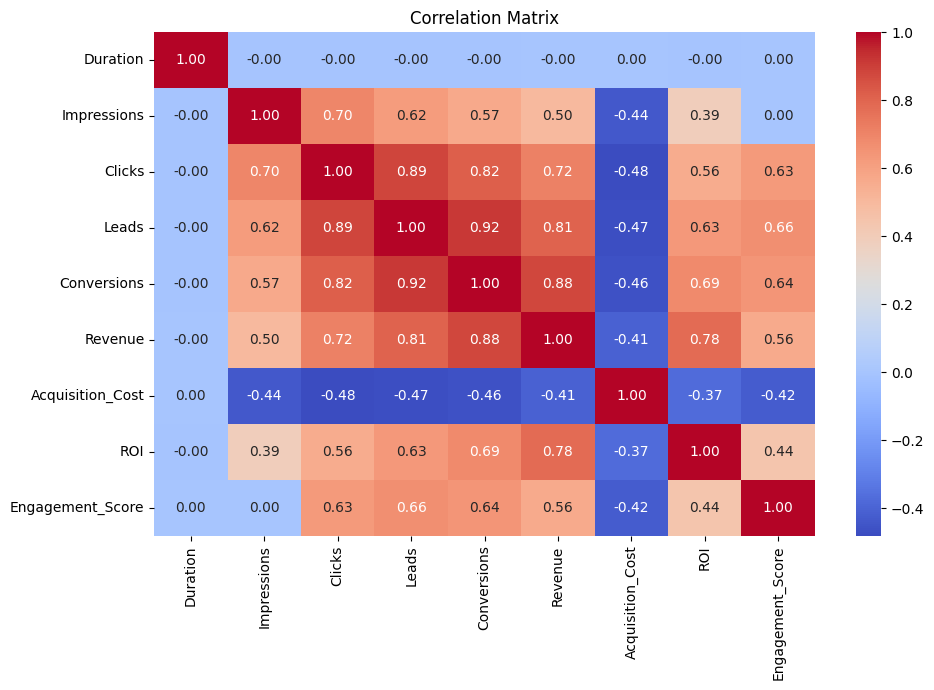

In [98]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [99]:
print("Clicks > Impressions:", (df["Clicks"] > df["Impressions"]).sum())
print("Leads > Clicks:", (df["Leads"] > df["Clicks"]).sum())
print("Conversions > Leads:", (df["Conversions"] > df["Leads"]).sum())

Clicks > Impressions: 0
Leads > Clicks: 0
Conversions > Leads: 0


In [100]:
# ensuring the law : ROI = Revenue / (Acquisition_Cost * Conversions) - 1
roi_formula = df["Revenue"] / (df["Acquisition_Cost"] * df["Conversions"]) - 1
diff = (roi_formula - df["ROI"]).abs()

print("Median diff:", diff.median())
print("Exact matches (<0.01):", (diff < 0.01).sum(), "/", len(df))
print("Correlation:", roi_formula.corr(df["ROI"]))

Median diff: 0.0025048169556838307
Exact matches (<0.01): 166548 / 166665
Correlation: 0.9999997837558934


these columns (Revenue , Acquisition_Cost , Conversions) can't be used as a feature because of leakage so we changed the target from ROI to Conversions

In [101]:
ratio = df["Conversions"] / df["Leads"]
print(ratio.describe())

funnel_cols = ["Impressions", "Clicks", "Leads", "Conversions", "Revenue"]
print()
print(df[funnel_cols].corr())


count    166665.000000
mean          0.549601
std           0.144450
min           0.288136
25%           0.424242
50%           0.550072
75%           0.674476
max           0.799931
dtype: float64

             Impressions    Clicks     Leads  Conversions   Revenue
Impressions     1.000000  0.695006  0.618854     0.567175  0.497593
Clicks          0.695006  1.000000  0.889196     0.816430  0.716249
Leads           0.618854  0.889196  1.000000     0.918074  0.806366
Conversions     0.567175  0.816430  0.918074     1.000000  0.878952
Revenue         0.497593  0.716249  0.806366     0.878952  1.000000


# **Preprocessing**

In [102]:
df = df.drop("Campaign_ID", axis=1)

In [103]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df = df.drop("Date", axis=1)

print(df["Year"].value_counts())

Year
2024    88705
2025    77960
Name: count, dtype: int64


In [104]:
channels = ["Facebook", "WhatsApp", "Google", "YouTube", "Instagram", "Email"]

for channel in channels:
    df[channel] = df["Channel_Used"].str.contains(channel, regex=False).astype(int)

df = df.drop("Channel_Used", axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166665 entries, 0 to 166664
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_Type     166665 non-null  object 
 1   Target_Audience   166665 non-null  object 
 2   Duration          166665 non-null  int64  
 3   Impressions       166665 non-null  int64  
 4   Clicks            166665 non-null  int64  
 5   Leads             166665 non-null  int64  
 6   Conversions       166665 non-null  int64  
 7   Revenue           166665 non-null  int64  
 8   Acquisition_Cost  166665 non-null  float64
 9   ROI               166665 non-null  float64
 10  Language          166665 non-null  object 
 11  Engagement_Score  166665 non-null  float64
 12  Customer_Segment  166665 non-null  object 
 13  Brand             166665 non-null  object 
 14  Year              166665 non-null  int32  
 15  Month             166665 non-null  int32  
 16  Facebook          16

In [105]:
df["Conversions"] = np.log1p(df["Conversions"])

In [106]:
target_col = "Conversions"

features = [
    "Impressions", "Clicks", "Leads",
    "Brand", "Campaign_Type", "Target_Audience", "Language", "Customer_Segment",
    "Duration", "Year", "Month",
    "Facebook", "WhatsApp", "Google", "YouTube", "Instagram", "Email",
]

X = df[features]
y = df[target_col]

print(X.shape, y.shape)


(166665, 17) (166665,)


In [107]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state= 42
)

print(X_train.shape, X_test.shape)

(133332, 17) (33333, 17)


# **One Hot Encoding + Scaling**

In [108]:
categorical_features = [
    "Brand", "Campaign_Type", "Target_Audience", "Language", "Customer_Segment"
]

numerical_features = [
    "Impressions", "Clicks", "Leads",
    "Duration", "Year", "Month",
    "Facebook", "WhatsApp", "Google", "YouTube", "Instagram", "Email",
]

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features),
    ]
)

preprocessor_plain = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="passthrough"
)


# **Modeling**

In [109]:
models = {
    "Baseline (Mean)": Pipeline([
        ("prep", preprocessor_plain),
        ("model", DummyRegressor(strategy="mean"))
    ]),
    "Ridge Regression": Pipeline([
        ("prep", preprocessor_scaled),
        ("model", Ridge(alpha=10))
    ]),
    "Decision Tree": Pipeline([
        ("prep", preprocessor_plain),
        ("model", DecisionTreeRegressor(
            max_depth=8, min_samples_leaf=5, random_state=42
        ))
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocessor_plain),
        ("model", RandomForestRegressor(
            n_estimators=20, max_depth=14, min_samples_leaf=2,
            random_state=42, n_jobs=-1
        ))
    ]),
}

print("Models:", list(models))

Models: ['Baseline (Mean)', 'Ridge Regression', 'Decision Tree', 'Random Forest']


In [110]:
results = []
trained_models = {}

for name, pipe in models.items():
    print(f"Training {name}...")
    start = time.time()

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)

    results.append({
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2 Score": r2_score(y_test, y_pred),
        "CV R2 (mean)": cv_r2.mean(),
        "CV R2 (std)": cv_r2.std(),
    })

    trained_models[name] = pipe
    print(f"  done in {time.time() - start:.1f}s")

results_df = pd.DataFrame(results).sort_values("R2 Score", ascending=False)
results_df

Training Baseline (Mean)...


  done in 9.3s
Training Ridge Regression...
  done in 6.2s
Training Decision Tree...
  done in 3.9s
Training Random Forest...
  done in 34.8s


,Model,RMSE,MAE,R2 Score,CV R2 (mean),CV R2 (std)
2,Decision Tree,0.279537,0.239359,0.901582,0.902852,0.000653
3,Random Forest,0.281279,0.240548,0.900352,0.901369,0.000582
1,Ridge Regression,0.442791,0.350189,0.753059,0.753699,0.001142
0,Baseline (Mean),0.891065,0.719881,-0.000031,-0.000016,0.000012


# **Feature Importance**

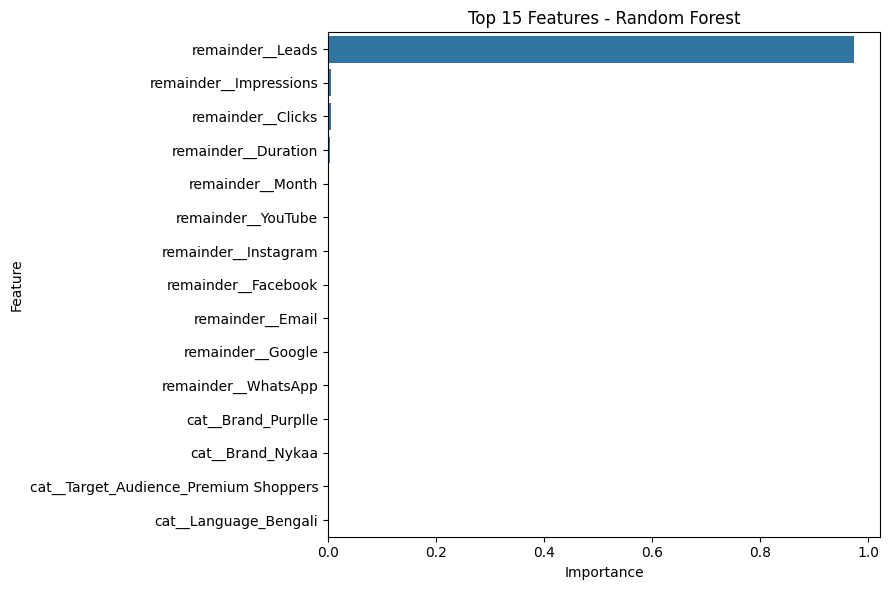

,Feature,Importance
24,remainder__Leads,0.972693
22,remainder__Impressions,0.005677
23,remainder__Clicks,0.005434
25,remainder__Duration,0.003131
27,remainder__Month,0.002160
31,remainder__YouTube,0.000490
32,remainder__Instagram,0.000477
28,remainder__Facebook,0.000459
33,remainder__Email,0.000452
30,remainder__Google,0.000452


In [111]:
best_name = "Random Forest"
best_pipe = trained_models[best_name]

feature_names = best_pipe.named_steps["prep"].get_feature_names_out()
importances = best_pipe.named_steps["model"].feature_importances_

imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=imp_df, x="Importance", y="Feature")
plt.title(f"Top 15 Features - {best_name}")
plt.tight_layout()
plt.show()

imp_df

# **Actual vs Predicted**

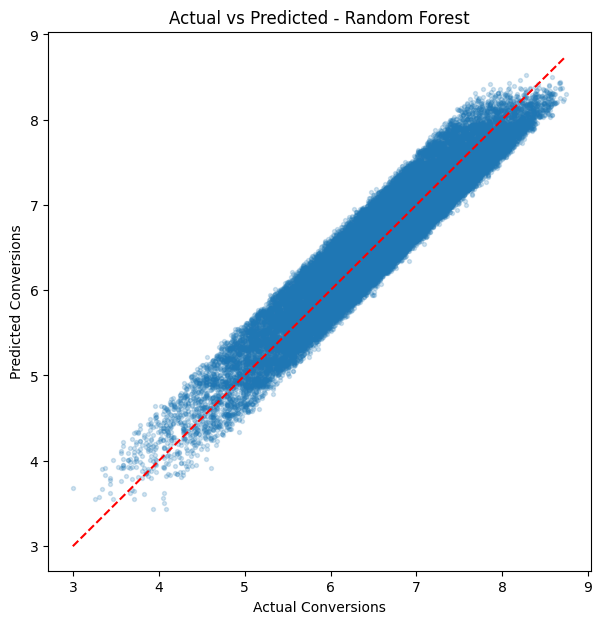

In [112]:
y_pred_best = best_pipe.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best, alpha=0.2, s=8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Conversions")
plt.ylabel("Predicted Conversions")
plt.title(f"Actual vs Predicted - {best_name}")
plt.show()

In [113]:
comparison_df = results_df[["Model", "RMSE", "MAE", "R2 Score", "CV R2 (mean)", "CV R2 (std)"]].copy()
comparison_df = comparison_df.reset_index(drop=True)
comparison_df.round(3)

,Model,RMSE,MAE,R2 Score,CV R2 (mean),CV R2 (std)
0,Decision Tree,0.280,0.239,0.902,0.903,0.001
1,Random Forest,0.281,0.241,0.900,0.901,0.001
2,Ridge Regression,0.443,0.350,0.753,0.754,0.001
3,Baseline (Mean),0.891,0.720,-0.000,-0.000,0.000


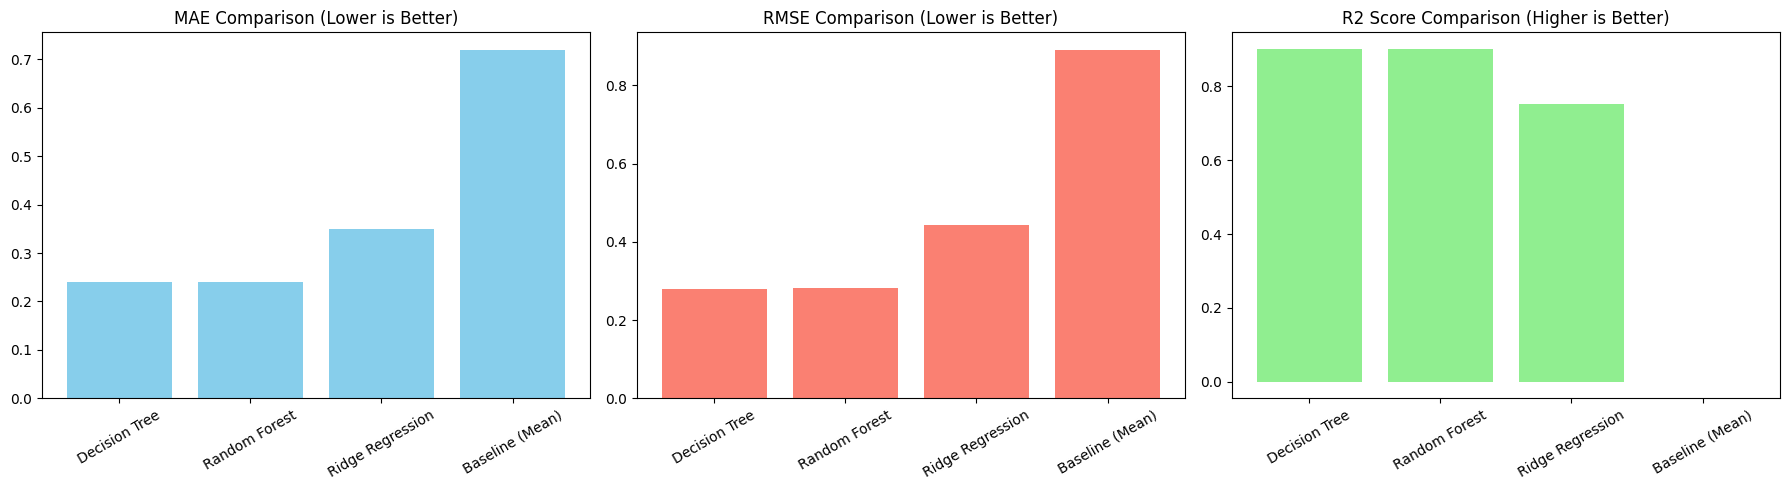

In [114]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(results_df["Model"], results_df["MAE"], color="skyblue")
axes[0].set_title("MAE Comparison (Lower is Better)")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(results_df["Model"], results_df["RMSE"], color="salmon")
axes[1].set_title("RMSE Comparison (Lower is Better)")
axes[1].tick_params(axis="x", rotation=30)

axes[2].bar(results_df["Model"], results_df["R2 Score"], color="lightgreen")
axes[2].set_title("R2 Score Comparison (Higher is Better)")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

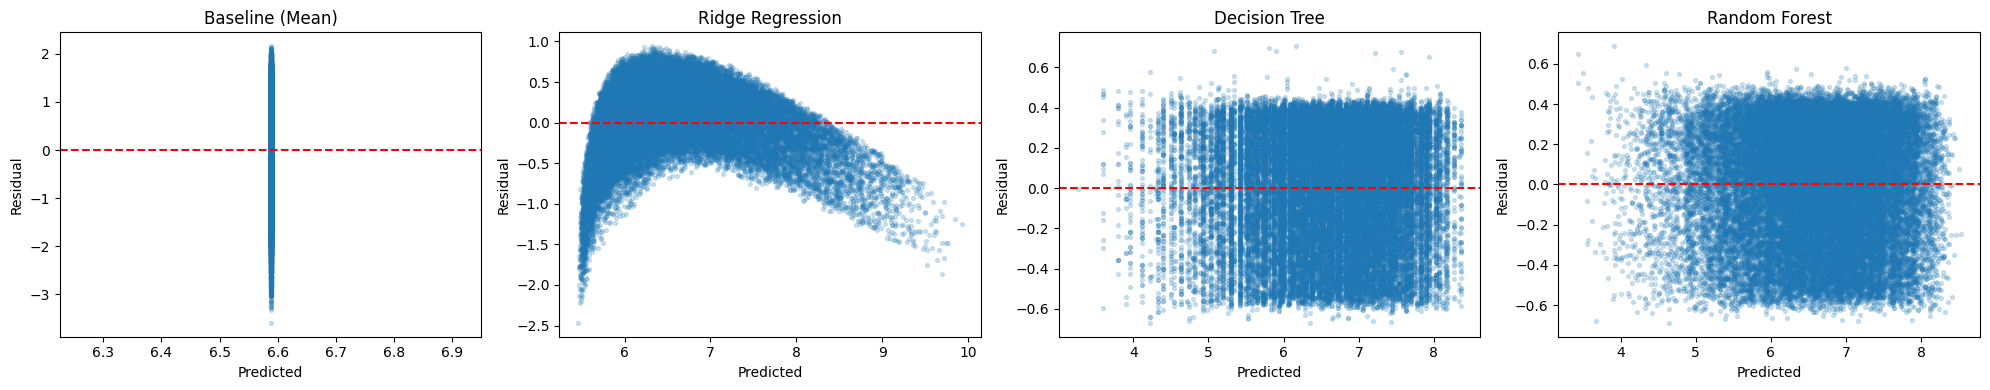

In [115]:
fig, axes = plt.subplots(1, len(trained_models), figsize=(20, 4))

for ax, (name, pipe) in zip(axes, trained_models.items()):
    y_pred = pipe.predict(X_test)
    residuals = y_test - y_pred

    ax.scatter(y_pred, residuals, alpha=0.2, s=8)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual")

plt.tight_layout()
plt.show()

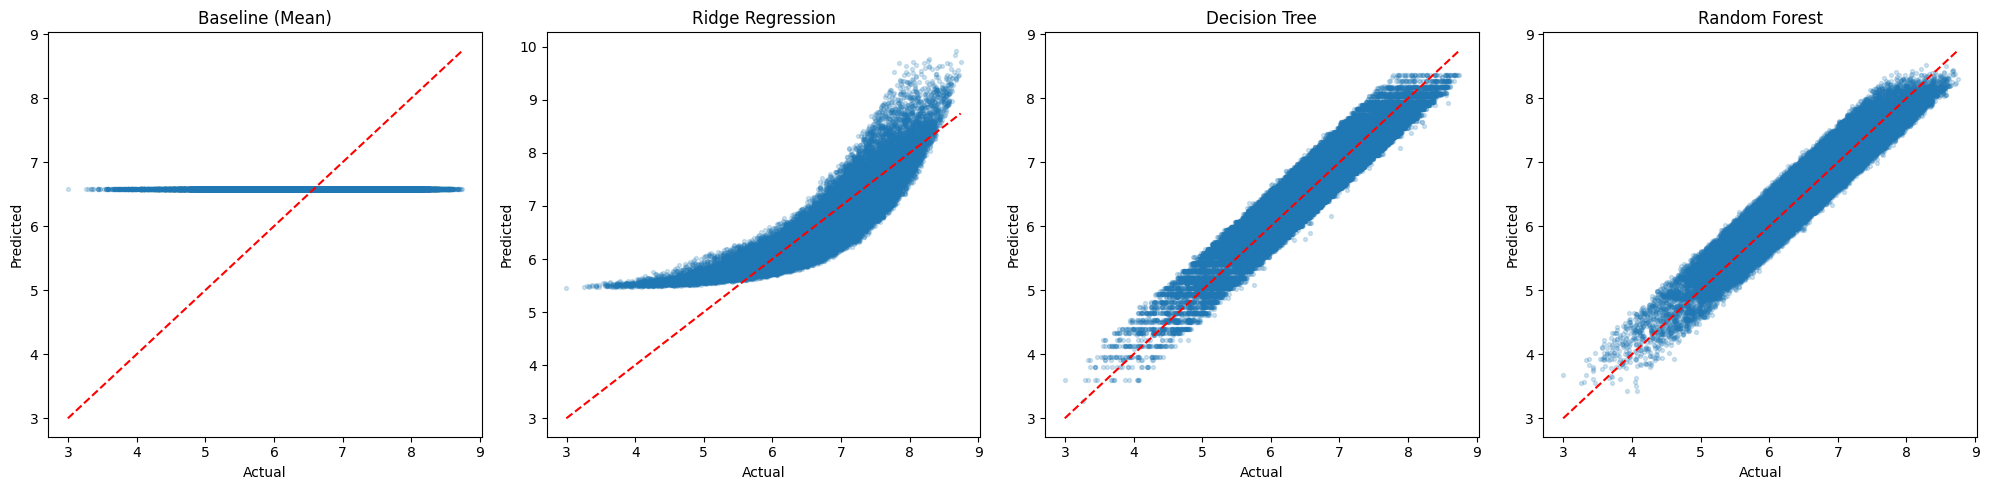

In [116]:
fig, axes = plt.subplots(1, len(trained_models), figsize=(20, 5))

for ax, (name, pipe) in zip(axes, trained_models.items()):
    y_pred = pipe.predict(X_test)

    ax.scatter(y_test, y_pred, alpha=0.2, s=8)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    ax.set_title(name)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

plt.tight_layout()
plt.show()

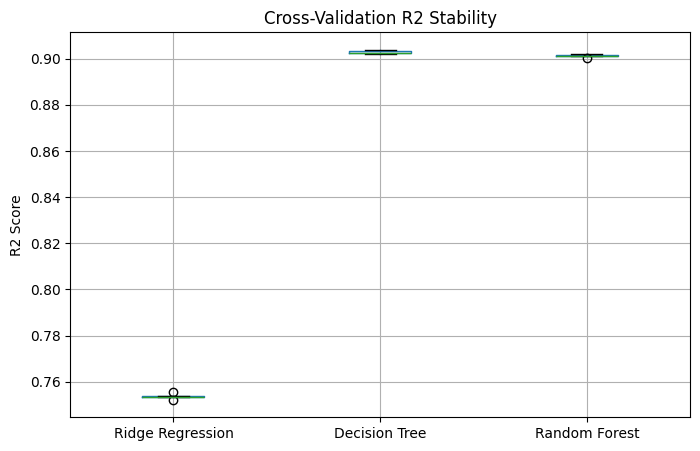

In [117]:
cv_results = {}

for name, pipe in trained_models.items():
    if name == "Baseline (Mean)":
        continue
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)
    cv_results[name] = scores

cv_df = pd.DataFrame(cv_results)

plt.figure(figsize=(8, 5))
cv_df.boxplot()
plt.ylabel("R2 Score")
plt.title("Cross-Validation R2 Stability")
plt.show()

In [119]:
training_times = {}

for name, pipe in trained_models.items():
    start = time.time()
    pipe.fit(X_train, y_train)
    training_times[name] = time.time() - start

cv_range = cv_df.max() - cv_df.min()

summary_df = comparison_df.copy()
summary_df["CV_R2_range"] = summary_df["Model"].map(cv_range)
summary_df["Training_Time_s"] = summary_df["Model"].map(training_times)

summary_df

,Model,RMSE,MAE,R2 Score,CV R2 (mean),CV R2 (std),CV_R2_range,Training_Time_s
0,Decision Tree,0.279537,0.239359,0.901582,0.902852,0.000653,0.001751,1.131045
1,Random Forest,0.281279,0.240548,0.900352,0.901369,0.000582,0.001765,5.049409
2,Ridge Regression,0.442791,0.350189,0.753059,0.753699,0.001142,0.003548,0.267275
3,Baseline (Mean),0.891065,0.719881,-0.000031,-0.000016,0.000012,NaN,0.200467
